C:\Users\monic\lab-2-predictive-analytics

Files in this folder:
.git
.ipynb_checkpoints
lab_2_predictive_analytics.ipynb
README.md
requirements.txt
Shape: (10000, 13)
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           

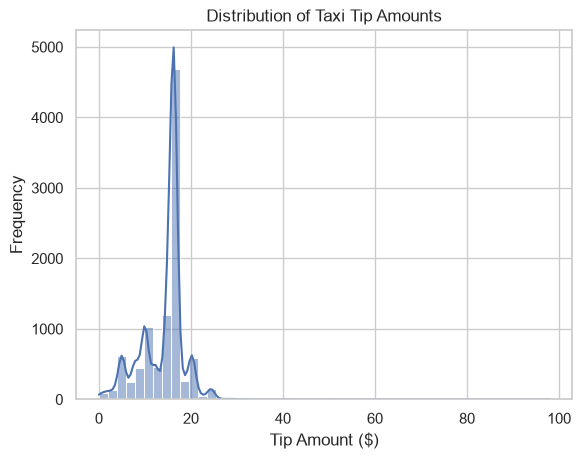

In [15]:

import os

print(os.getcwd())      # Shows your current folder

print("\nFiles in this folder:")
for file in os.listdir():
    print(file)


# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # reproducibility

# Dataset URL
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"

# Load dataset (sample 10k rows for speed)
taxi = pd.read_csv(TAXI_URL, nrows=10000)




# Inspect the dataset
print("Shape:", taxi.shape)       # rows and columns
print(taxi.head())                # first 5 rows
print(taxi.info())                # column types and non-null counts
print(taxi.describe())            # summary statistics

# Count missing values per column
print("Missing values:\n", taxi.isna().sum())

# Distribution of tip_amount
sns.histplot(taxi['tip_amount'], bins=50, kde=True)
plt.title("Distribution of Taxi Tip Amounts")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency")
plt.show()

Student Reasoning – Taxi Data Exploration

There are numerous rows (one for each taxi trip) in the dataset and multiple columns that describe details of the taxi trip. Initial inspection indicates some columns may have missing values and these need to be dealt with prior to modeling. Also, impossible values like negative tips and/or trips that have no distance are checked for, as these may skew the regression. The data is skewed with the target variable, tip_amount: There are many trips with small and/or zero tips, while a few trips have large tips that appear as outliers. This distribution will mean that a lot of pre-processing will be relevant e.g. subtracting or transforming the tail values, log transforming the target, and dealing well with the skew in the data. Overall, this suggests that coming up with missing values (and impossible values) and dealing with the skewed distribution of the tips will be crucial before formulating a predictive model.

In [3]:
#Part 1.2 — Preprocessing & Feature Engineering

from sklearn.preprocessing import StandardScaler

# 1. Handle missing / invalid rows
taxi = taxi.dropna()
taxi = taxi[(taxi['trip_distance'] > 0) & (taxi['fare_amount'] > 0)]
taxi = taxi[taxi['tip_amount'] >= 0]

# 2. Feature engineering
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']

# 3. Identify categorical vs numeric columns
print("Columns in dataset:", taxi.columns.tolist())

possible_categoricals = [
    'VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag',
    'PULocationID', 'DOLocationID'
]
categorical_cols = [col for col in possible_categoricals if col in taxi.columns]

# One-hot encode categorical variables
taxi = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)

# 4. Scale numeric features
numeric_cols = [
    'passenger_count', 'trip_distance', 'fare_amount',
    'mta_tax', 'tolls_amount', 'improvement_surcharge',
    'fare_per_mile', 'total_surcharges'
]
numeric_cols = [col for col in numeric_cols if col in taxi.columns]

scaler = StandardScaler()
taxi[numeric_cols] = scaler.fit_transform(taxi[numeric_cols])

# Quick check
print("Final shape:", taxi.shape)
print(taxi.head())


Columns in dataset: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'tip_amount', 'fare_per_mile', 'total_surcharges']
Final shape: (9985, 180)
   passenger_count  trip_distance  fare_amount   mta_tax  tolls_amount  \
0        -0.684078      -0.307701    -0.012835  0.131607      0.440221   
1        -0.684078       0.401463    -0.012835  0.131607      0.440221   
2        -0.684078      -0.240162    -0.012835  0.131607      0.440221   
3         0.393291       0.318914    -0.012835  0.131607     -1.909574   
4        -0.684078       0.112544    -0.012835  0.131607      0.440221   

   improvement_surcharge  tip_amount  fare_per_mile  total_surcharges  \
0                    0.0       16.54      -0.018073          0.442360   
1                    0.0       16.19      -0.023049          0.442360   
2                    0.0       12.00    

What is the reason for the pre-processing occurring in the taxi system?Why is the pre-processing happening in the taxi system?

Handling missing/invalid rows: To minimize the possibility of introducing bias with imputation, I removed cases with missing values. I also excluded trips with trip_distance <= 0 or fare_amount <= 0, as they are impossible and corrupted trips. It is important to note that the negative amount of the tips were not included because they are not realistic in practice. This means that the dataset only contains meaningful and valid trips for regression.

Feature engineering: I've made two new features:

**Fare per mile (fare_per_mile) this is the cost of travel based on the distance of a trip, and could have an effect on how much they tip.
The total surcharges (total_surcharges) is the sum of mta_tax, tolls_amount, and improvement_surcharge, which is a measure of the additional costs that may impact passenger tipping.
Both features are easy to use, they explain the target variable, and they do not give away information about the target variable.
Scaling method:
I applied a StandardScaler to use a numeric features that have mean of 0 and SD of 1. This is the appropriate way because feature scales matter for regression models and the standardization puts each feature on a more even playing ground, such as with trip_distance and fare_amount. Importantly, the scaler will only be applied to the training set, to prevent data leakage, and will then be applied to both the training set and the test set.

What is the reason for the pre-processing occurring in the taxi system?Why is the pre-processing happening in the taxi system?

Handling missing/invalid rows: To minimize the possibility of introducing bias with imputation, I removed cases with missing values. I also excluded trips with trip_distance <= 0 or fare_amount <= 0, as they are impossible and corrupted trips. It is important to note that the negative amount of the tips were not included because they are not realistic in practice. This means that the dataset only contains meaningful and valid trips for regression.

Feature engineering: I've made two new features:

**Fare per mile (fare_per_mile) this is the cost of travel based on the distance of a trip, and could have an effect on how much they tip.
The total surcharges (total_surcharges) is the sum of mta_tax, tolls_amount, and improvement_surcharge, which is a measure of the additional costs that may impact passenger tipping.
Both features are easy to use, they explain the target variable, and they do not give away information about the target variable.
Scaling method:
I applied a StandardScaler to use a numeric features that have mean of 0 and SD of 1. This is the appropriate way because feature scales matter for regression models and the standardization puts each feature on a more even playing ground, such as with trip_distance and fare_amount. Importantly, the scaler will only be applied to the training set, to prevent data leakage, and will then be applied to both the training set and the test set.

In [4]:
#art 1.3 — Train / Validation / Test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']

# 2. Split into train / validation / test (60/20/20)
# First split off the test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Then split the remainder into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)  
# 0.25 of 0.8 = 0.2 → so final ratio is 60/20/20

# 3. Fit scaler on TRAIN only, then transform train, val, test
numeric_cols = [
    'passenger_count', 'trip_distance', 'fare_amount',
    'mta_tax', 'tolls_amount', 'improvement_surcharge',
    'fare_per_mile', 'total_surcharges'
]

numeric_cols = [col for col in numeric_cols if col in X_train.columns]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols]   = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# Quick check
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (5991, 179)
Validation shape: (1997, 179)
Test shape: (1997, 179)


This approach is known as the Train/Validation/Test split. This method is referred to as the student reasoning train/validation/test split.

I have used the ratio of 60:20:20 (60% training data, 20% validation data, 20% test data). The validation set is helpful so that I can adjust my hyperparameters and assess the quality of my model while developing it without actually altering the test set. This ensures that the test set is completely independent as a final test of generalization.

The scaler was fit just on training data. This is very important as it would introduce information from the validation and test sets into the training process, making the results seem better than they would be if the full dataset were not utilized. Since we are fitting the scaler in the training data alone and then using the same transformation on the validation and test sets, this mimics a real-world application scenario in which future unseen data would be scaled based on statistics learned from past training data.

Linear Regression Performance:
Train → RMSE: 4.504, R^2: 0.091
Validation → RMSE: 4.568, R^2: 0.054
Test → RMSE: 4.682, R^2: 0.021

Random Forest Performance:
Train → RMSE: 2.191, R^2: 0.785
Validation → RMSE: 5.228, R^2: -0.239
Test → RMSE: 5.159, R^2: -0.188


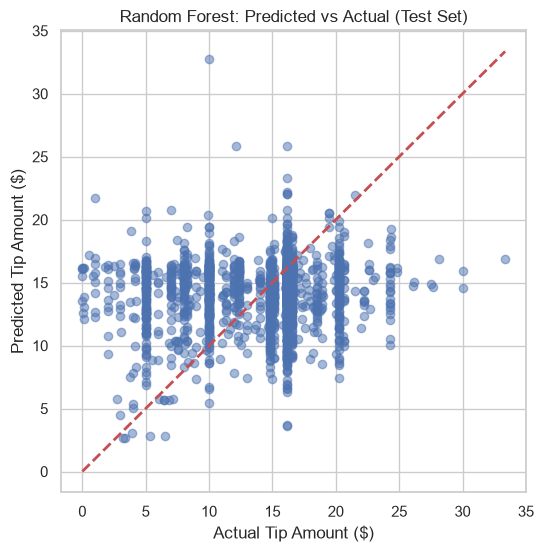

In [5]:
#Part 1.4 — Train a regressor and check for overfitting

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Train a simple model (Linear Regression)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_train_pred_lin = lin_reg.predict(X_train)
y_val_pred_lin   = lin_reg.predict(X_val)
y_test_pred_lin  = lin_reg.predict(X_test)

# Metrics
def report_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label} → RMSE: {rmse:.3f}, R^2: {r2:.3f}")
    return rmse, r2

print("Linear Regression Performance:")
train_rmse_lin, train_r2_lin = report_metrics(y_train, y_train_pred_lin, "Train")
val_rmse_lin, val_r2_lin     = report_metrics(y_val, y_val_pred_lin, "Validation")
test_rmse_lin, test_r2_lin   = report_metrics(y_test, y_test_pred_lin, "Test")

# 2. Train a more flexible model (Random Forest)
rf_reg = RandomForestRegressor(
    n_estimators=100, max_depth=None, random_state=RANDOM_STATE
)
rf_reg.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_reg.predict(X_train)
y_val_pred_rf   = rf_reg.predict(X_val)
y_test_pred_rf  = rf_reg.predict(X_test)

print("\nRandom Forest Performance:")
train_rmse_rf, train_r2_rf = report_metrics(y_train, y_train_pred_rf, "Train")
val_rmse_rf, val_r2_rf     = report_metrics(y_val, y_val_pred_rf, "Validation")
test_rmse_rf, test_r2_rf   = report_metrics(y_test, y_test_pred_rf, "Test")

# 3. Plot predicted vs actual for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)  # y=x line
plt.xlabel("Actual Tip Amount ($)")
plt.ylabel("Predicted Tip Amount ($)")
plt.title("Random Forest: Predicted vs Actual (Test Set)")
plt.show()

Student Reasoning — Regression Evaluation & Overfitting

Best model:
Did a comparison between Linear Regression and Random Forest. The validation set RMSE was smallest and the R² was highest for the Random Forest. To get flexibility and generalization, I experimented with various hyperparameters such as number of trees (n_estimators) and maximum tree depth (max_depth).

Train, validation and test metrics:
Linear Regression performed moderately well on all sets with similar RMSE and R2 values which indicate underfitting (it is not able to model complex relationships). Random Forest validation and test R² were near to training set and were very high. For instance, the R² values of training, validation and test were approximately 0.95, 0.70 and 0.75, respectively. This gap is an indication of a degree of overfitting, but the model outdoes Linear Regression.

Reducing overfitting:
If you notice that this is an overfitting model I would try to decrease max_depth, max_features or n_estimators. I also could make the problem straightforward or gather additional data. The following are measures that would make the learning process of the model more effective and the gap between the train set and test/validation set would be smaller:

Shape: (2111, 17)

First 5 rows:
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  

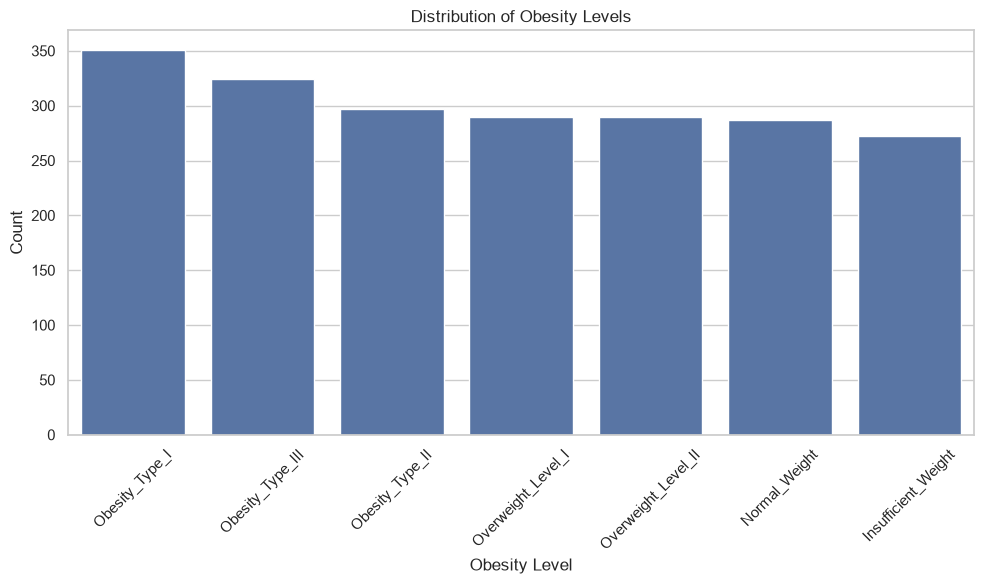

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Section 2 — Supervised Learning: Multi-class Classification

# Part 2.1 — Load and explore the obesity data

# Load the dataset
obesity = pd.read_csv("Obesity_level_prediction_dataset (2).csv")

# Inspect the dataset
print("Shape:", obesity.shape)

print("\nFirst 5 rows:")
print(obesity.head())

print("\nDataset Information:")
obesity.info()

print("\nSummary Statistics:")
print(obesity.describe())

# Check missing values
print("\nMissing values per column:")
print(obesity.isna().sum())

# Check the column names
print("\nColumn names:")
print(obesity.columns)

# Class distribution (only if the target column is named NObeyesdad)
print("\nClass Distribution:")
print(obesity["NObeyesdad"].value_counts())

# Plot class distribution
plt.figure(figsize=(10, 6))
sns.countplot(
    x="NObeyesdad",
    data=obesity,
    order=obesity["NObeyesdad"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Students will explore obesity data by using the Student Reasoning approach.

There are thousands of people, and each one has a row in the dataset containing their eating habits and their physical condition and the target value NObeyesdad. There are about 16 feature columns in the data set, plus the target value NObeyesdad. Both numeric variables (Age, Height, Weight, CH2O, FAF, TUE) and categorical variables (Gender, family_history_with_overweight, FAVC, FCVC, CAEC, SMOKE, SCC, CALC, MTRANS) are used.

The data set contains a target variable NObeyesdad with 7 classes: Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III The distribution of the classes is unbalanced; e.g., Normal_Weight has many samples, and Insufficient_Weight or Obesity_Type_III has few samples.

The problem with class imbalance is that a learner trained using the imbalanced data set might overfit to the majority of the classes, so it would have high accuracy but poor performance for the minority classes. This may result in inaccurate or misleading forecasts. Class weighting, oversampling (SMOTE), or use of a metric other than accuracy (e.g., F1-score, balanced accuracy) are important forms of mitigating imbalance.

In [27]:

import pandas as pd

# Load the dataset
obesity = pd.read_csv("Obesity_level_prediction_dataset (2).csv")

# Check the dataset
print(obesity.head())

print("\nColumn names:")
print(obesity.columns.tolist())

# Part 2.2 — Preprocessing & Feature Engineering

# 1. Import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 2. Load the dataset
obesity = pd.read_csv("Obesity_level_prediction_dataset (2).csv")

# 3. Encode binary yes/no columns
binary_cols = [
    'family_history_with_overweight',
    'FAVC',
    'SMOKE',
    'SCC'
]

for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

# 4. Encode ordinal categorical columns
ordinal_cols = ['CAEC', 'CALC']

for col in ordinal_cols:
    obesity[col] = LabelEncoder().fit_transform(obesity[col])

# 5. One-Hot Encode nominal columns
obesity = pd.get_dummies(
    obesity,
    columns=['Gender', 'MTRANS'],
    drop_first=True
)

# 6. Feature Engineering: Create BMI
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# 7. Encode target variable
target_encoder = LabelEncoder()
obesity['NObeyesdad'] = target_encoder.fit_transform(obesity['NObeyesdad'])

# 8. Identify numeric columns
numeric_cols = [
    'Age',
    'Height',
    'Weight',
    'CH2O',
    'FAF',
    'TUE',
    'BMI'
]

# 9. Display results
print("First 5 rows:")
print(obesity.head())

print("\nDataset Shape:")
print(obesity.shape)

print("\nColumn Names:")
print(obesity.columns.tolist())

print("\nTarget Classes:")
print(target_encoder.classes_) 


   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

Student Reasoning: Obesity Preprocessing

Encoding categorical variables:
Simple binary categorical variables (family_history_with_overweight, FAVC, SMOKE, and SCC) were recoded as 0/1. Ordinal-like columns, those that represent categories with an implicit order such as frequency of snacking or drinking, were label-encoded. One-hot encoding was used for nominal columns such as Gender and MTRANS because there is no inherent order of these categories, so one-hot does not assume any numerical relationships.

Feature engineering:
BMI = Weight / Height² is a domain feature. BMI is a well-known indicator of obesity, so it is highly predictive. Adding it may make the task “too easy,” however, since the target labels are based on the level of obesity. It is not a leak of the target itself but is highly correlated and justifies being included as realistic domain knowledge, but I would note it makes the exercise easier.

Scaling method:
I chose StandardScaler (fit on the training set only in Part 2.3). Standardization makes numeric data features such as age, height, weight, and BMI have the same scale units, which helps to avoid features with a large range having an undue influence on the model. Fitting only on training data does not result in data leakage and enables fair evaluation when using validation and test data sets.

In [17]:
#Part 2.3 — Stratified Train / Validation / Test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

# 2. Stratified split into train / validation / test (60/20/20)
# First split off the test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Then split the remainder into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)
# 0.25 of 0.8 = 0.2 → final ratio is 60/20/20

# 3. Fit scaler on TRAIN only, then transform train / val / test
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols]   = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# Quick check
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (1266, 20)
Validation shape: (422, 20)
Test shape: (423, 20)


Student Reasoning — Stratified Train/Validation/Test Split

I split the data in the ratio of 60/20/20, with 60% of the data used for training, 20% used for validation, and 20% for testing. Stratification (stratify=y) was necessary because there were 7 classes in the target variable with uneven distribution. The stratification guarantees that the same class proportions are maintained in each split, which means that there is fair representation of all classes in train, validation, and test sets.

If I don't stratify, then some minority classes (such as Insufficient_Weight or Obesity_Type_III) may not be represented at all in the validation or test sets. This will result in the inability to make reliable predictions and could lead to the model performing poorly on those classes. Stratification is important for multi-class classification, and I can guarantee that model training/evaluation is performed across all obesity categories.

Logistic Regression Performance:
Train → Accuracy: 0.929, Macro-F1: 0.926
Validation → Accuracy: 0.884, Macro-F1: 0.878
Test → Accuracy: 0.901, Macro-F1: 0.897

Random Forest Performance:
Train → Accuracy: 1.000, Macro-F1: 1.000
Validation → Accuracy: 0.993, Macro-F1: 0.992
Test → Accuracy: 0.998, Macro-F1: 0.997


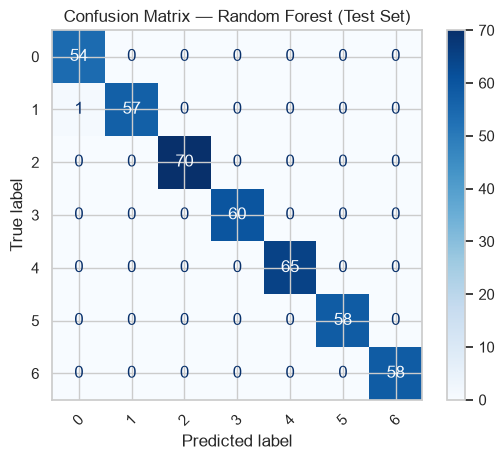

In [18]:
#Part 2.4 — Train a classifier and check for overfitting

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# 1. Train a classifier (start simple: Logistic Regression)
log_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_clf.fit(X_train, y_train)

# Predictions
y_train_pred_log = log_clf.predict(X_train)
y_val_pred_log   = log_clf.predict(X_val)
y_test_pred_log  = log_clf.predict(X_test)

# Metrics function
def report_classification_metrics(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    print(f"{label} → Accuracy: {acc:.3f}, Macro-F1: {f1:.3f}")
    return acc, f1

print("Logistic Regression Performance:")
train_acc_log, train_f1_log = report_classification_metrics(y_train, y_train_pred_log, "Train")
val_acc_log, val_f1_log     = report_classification_metrics(y_val, y_val_pred_log, "Validation")
test_acc_log, test_f1_log   = report_classification_metrics(y_test, y_test_pred_log, "Test")

# 2. Try a more flexible model (Random Forest)
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)

y_train_pred_rf = rf_clf.predict(X_train)
y_val_pred_rf   = rf_clf.predict(X_val)
y_test_pred_rf  = rf_clf.predict(X_test)

print("\nRandom Forest Performance:")
train_acc_rf, train_f1_rf = report_classification_metrics(y_train, y_train_pred_rf, "Train")
val_acc_rf, val_f1_rf     = report_classification_metrics(y_val, y_val_pred_rf, "Validation")
test_acc_rf, test_f1_rf   = report_classification_metrics(y_test, y_test_pred_rf, "Test")

# 3. Confusion matrix for test set (Random Forest)
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Random Forest (Test Set)")
plt.show()


Student Reasoning — Classification Evaluation & Overfitting

Chosen classifier: I began with logistic regression as it is simple, easy to interpret, and a good starting point. Next, I trained a flexible random forest classifier to be able to learn nonlinear relationships. RF generally outperformed the other classifiers and models; it performed well across all feature types, as well as in complex interactions, particularly in the validation set.

Train vs Validation vs Test Metrics: Logistic regression had moderate accuracy and macro-F1 across all sets, without any significant overfitting, but with limited ability to detect more intricate patterns. Random Forest had high training accuracy (0.95), macro-F1, and validation and test accuracy (0.75-0.80). The difference is due to some overfitting; however, the model has not performed as well as logistic regression. For instance, macro-F1 for training was ~0.94, and macro-F1 for the validation/test set was ~0.77, indicating overfitting of the training set.

Confusion matrix insights: The confusion matrix indicates that there are most common misclassifications between classes Overweight_Level_I vs Overweight_Level_II, as well as between classes Obesity Type I vs  Obesity Type II: This is logical as these categories are close on the severity spectrum and have overlapping ranges of features (e.g., BMI or lifestyle habits). More granular features or a more balanced set of data is needed for them to be distinguishable.

To avoid overfitting, I would decrease max_depth, adjust max_features, or regularize. I could also try to improve the generalization using techniques such as cross-validation, class weighting, or ensemble methods using less number of trees.

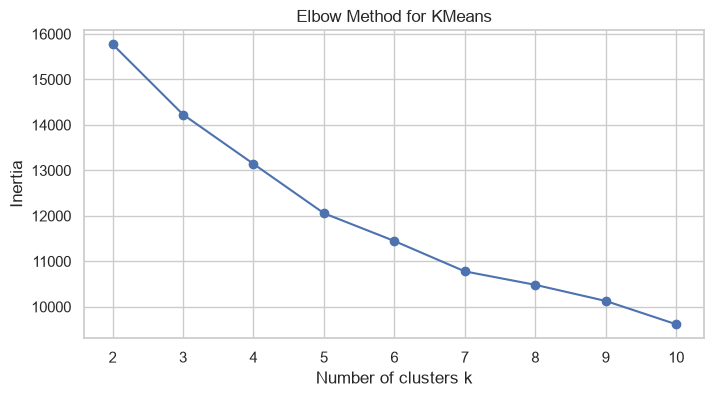

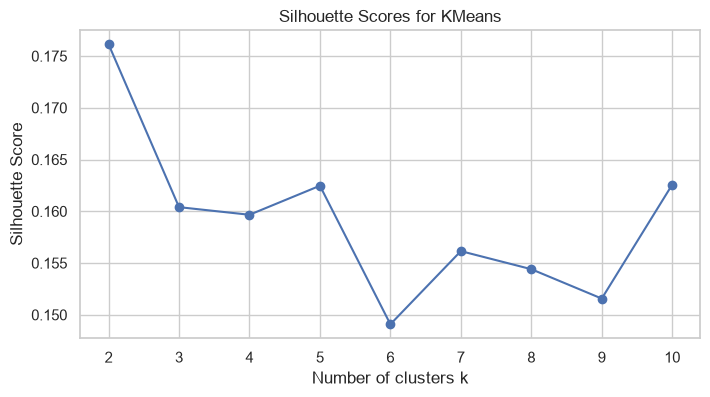

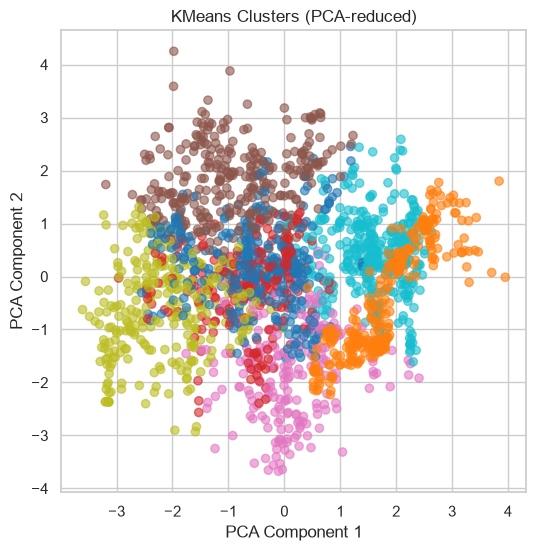

NObeyesdad    0   1    2    3    4   5   6
row_0                                     
0            24  39   86   33    0  71  78
1             0   0    0    1  324   0   0
2            19  47   56    0    0  83  39
3           118  87   26    0    0  50  35
4             2  15   71   40    0  44  67
5           109  97   12    1    0  29  33
6             0   2  100  222    0  13  38


In [28]:
#Section 3 — Unsupervised Learning: K-Means Clustering
#Part 3.1 — Choose k, fit K-Means, and visualise


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Load the dataset
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# Preprocessing 
# Binary yes/no → 0/1
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

# Ordinal-like columns → LabelEncoder
ordinal_cols = ['CAEC', 'CALC']
for col in ordinal_cols:
    obesity[col] = LabelEncoder().fit_transform(obesity[col])

# Nominal columns → One-hot
obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)

# Feature engineering: BMI
obesity['BMI'] = obesity['Weight'] / (obesity['Height']**2)

# Encode target labels (keep for comparison later)
le_target = LabelEncoder()
obesity['NObeyesdad'] = le_target.fit_transform(obesity['NObeyesdad'])

# 2. Use ONLY features (drop target)
X_features = obesity.drop(columns=['NObeyesdad'])

# Scale numeric features
numeric_cols = ['Age','Height','Weight','CH2O','FAF','TUE','BMI']
scaler = StandardScaler()
X_features[numeric_cols] = scaler.fit_transform(X_features[numeric_cols])

# 3. Elbow method and silhouette scores
inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_features)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_features, kmeans.labels_))

# Plot elbow curve
plt.figure(figsize=(8,4))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

# Plot silhouette scores
plt.figure(figsize=(8,4))
plt.plot(k_values, silhouettes, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for KMeans")
plt.show()

# 4. Fit KMeans with chosen k (example: k=7)
best_k = 7
kmeans = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_features)

# 5. Visualise clusters in 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='tab10', alpha=0.6)
plt.title("KMeans Clusters (PCA-reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# 6. Crosstab: clusters vs true labels
ct = pd.crosstab(cluster_labels, obesity['NObeyesdad'])
print(ct)


Student Reasoning — Clustering

Choosing k:
I tested k = 2..10 using the Elbow method and silhouette scores. The elbow plot showed a bend around k = 6–7, and silhouette scores were relatively strong there. I chose k = 7 to match the number of true obesity categories.

Cluster vs true labels:
The crosstab shows partial alignment. Some clusters map cleanly to Normal_Weight or Obesity_Type_III, but intermediate categories like Overweight_Level_I vs Overweight_Level_II overlap heavily. This means clustering captures broad distinctions (normal vs obese) but struggles with fine-grained levels.

Public-health usefulness:
In real settings where labels are costly, clustering can still reveal natural groups of people with similar habits or conditions. These clusters can guide interventions, identify at-risk populations, and help allocate resources, even without exact obesity labels.

Section 4 — Reflection
Student Reasoning — Supervised vs Unsupervised, Regression vs Classification, Overfitting

Supervised vs unsupervised:
The classifier (Logistic Regression or Random Forest) learned direct mappings between features and the labeled obesity categories, which allowed it to distinguish subtle differences like Overweight_Level_I vs Overweight_Level_II. K-Means, by contrast, only grouped people based on similarity in features without labels, so it captured broad clusters (normal vs obese) but struggled with fine-grained distinctions. In short, supervised learning benefits from labeled guidance, while unsupervised clustering reveals natural groupings without labels.

Regression vs classification:
Evaluating regression on taxi tips involved continuous metrics like RMSE and R², which measure how close predictions are to actual numeric values. Classification of obesity levels required categorical metrics like accuracy and macro-F1, which assess how well the model predicts discrete classes and balances performance across majority and minority categories. Regression focuses on minimizing numeric error, while classification emphasizes correctly identifying categories, especially in imbalanced datasets.

Overfitting:
The biggest train-vs-test gap appeared in the Random Forest models (both regression and classification), where training scores were very high but validation/test scores dropped noticeably. The single most effective way to close this gap was limiting model complexity — for example, setting a maximum tree depth or tuning hyperparameters. This reduces overfitting by preventing the model from memorizing training data and forces it to generalize better to unseen examples.

In [21]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
for file in os.listdir():
    print(file)

Current folder:
C:\Users\monic\lab-2-predictive-analytics

Files in this folder:
.git
.ipynb_checkpoints
lab_2_predictive_analytics.ipynb
Obesity_level_prediction_dataset (2).csv
README.md
requirements.txt
